In [1]:
import json
from pathlib import Path

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch08_v3"

In [3]:
batches, steps = [], []
train_losses, val_losses = [], []
learning_rates, created_at = [], []

json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    tag = f.name.replace("checkpoint_", "").replace(".json", "")
    batches.append(int(tag.split("-", 1)[0]))
    steps.append(int(tag.split("-", 1)[-1]))
    train_losses.append(data['train_loss'])
    val_losses.append(data['val_loss'])
    learning_rates.append(data['learning_rate'])
    created_at.append(data['created_at'])

In [4]:
df = pd.DataFrame({
    "batches": batches,
    "steps": steps,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "learning_rate": learning_rates,
    "created_at": created_at,
})


df = df.sort_values(by='steps', ascending=True)

print(df.nsmallest(1, 'train_loss'))

df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

#pd.concat((df.head(10), df.tail(10)))
df

     batches    steps  train_loss  val_loss  learning_rate  \
142        7  1136000    0.816837  2.764172       0.000061   

                 created_at  
142  2025-09-13T02:48:00%:z  


,batches,steps,train_loss,val_loss,learning_rate,created_at
1,1,8000,4.540999,4.591301,0.000025,2025-09-10T00:22:20%:z
0,1,16000,3.703147,3.936172,0.000051,2025-09-10T00:42:57%:z
7,1,24000,2.812141,3.178871,0.000076,2025-09-10T01:03:33%:z
5,1,32000,2.404786,2.897669,0.000102,2025-09-10T01:24:09%:z
3,1,40000,2.162816,2.759679,0.000127,2025-09-10T01:44:47%:z
...,...,...,...,...,...,...
149,7,1192000,0.850782,2.758171,0.000051,2025-09-13T05:12:24%:z
150,7,1200000,0.849206,2.738098,0.000050,2025-09-13T05:33:02%:z
151,7,1208000,0.853620,2.733152,0.000049,2025-09-13T05:53:39%:z
152,7,1216000,0.849263,2.768948,0.000048,2025-09-13T06:14:17%:z


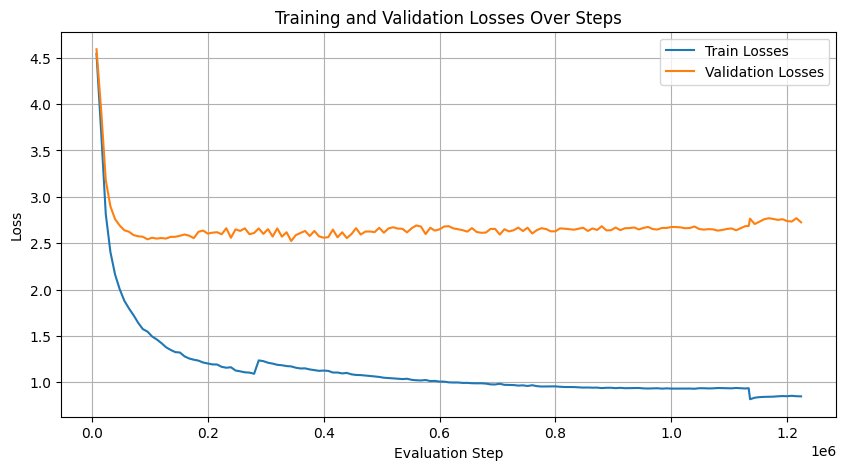

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['steps'], df['train_loss'], label="Train Losses")
plt.plot(df['steps'], df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Losses Over Steps")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

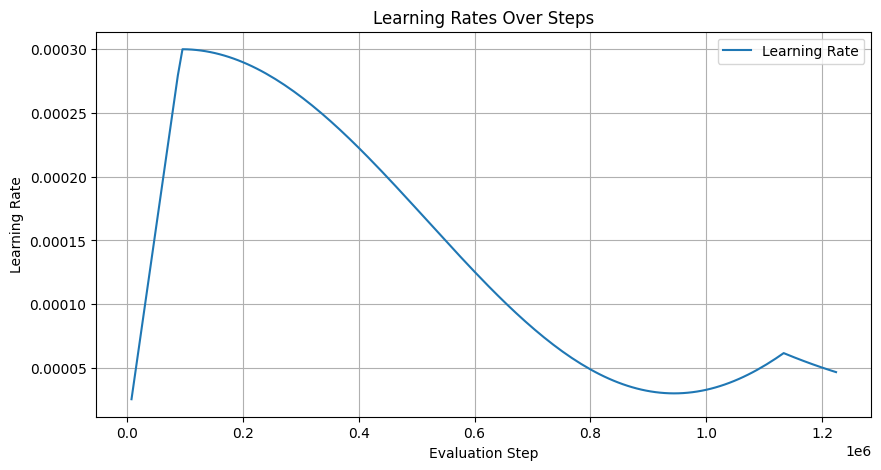

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['steps'], df['learning_rate'], label="Learning Rate")
plt.xlabel("Evaluation Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rates Over Steps")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")